# Проект: Обучение с учителем: качество модели      


### Описание проекта

Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. Сделать это можно с помощью персонализированных предложений.

«В один клик» — современная компания, поэтому её руководство не хочет принимать решения просто так — только на основе анализа данных и бизнес-моделирования. У компании есть небольшой отдел цифровых технологий, и мне предстоит побыть в роли стажёра в этом отделе. 

Итак, нашему отделу поручили разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.




### Как я буду решать задачу

Продумывать подход к решению этой задачи мне не придётся — руководитель отдела его уже сформировал:
Нужно промаркировать уровень финансовой активности постоянных покупателей. В компании принято выделять два уровня активности: «снизилась», если клиент стал покупать меньше товаров, и «прежний уровень».

Нужно собрать данные по клиентам по следующим группам:

Признаки, которые описывают коммуникацию сотрудников компании с клиентом.

Признаки, которые описывают продуктовое поведение покупателя. Например, какие товары покупает и как часто.

Признаки, которые описывают покупательское поведение клиента. Например, сколько тратил в магазине.

Признаки, которые описывают поведение покупателя на сайте. Например, как много страниц просматривает и сколько времени проводит на сайте.

Представим группы признаков (вместе с целевым) в виде диаграммы — такую визуализацию ещё называют диаграммой Исикавы.

На диаграмме входные признаки объединены в четыре группы: коммуникация с клиентом, продуктовое поведение, поведение на сайте и финансовое поведение.

Нужно построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца.
В исследование нужно включить дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца.

Используя данные модели и данные о прибыльности клиентов, нужно выделить сегменты покупателей и разработать для них персонализированные предложения.

Руководство одобрило описание решения, и мне, как специалисту по DS, нужно его реализовать.


### Инструкция по выполнению проекта

Решать задачу мне нужно в два этапа:

Разработайте модель, которая предскажет вероятность снижения покупательской активности.

Выделю сегмент покупателей, проанализирую его и предложу, как увеличить его покупательскую активность. Использую данные моделирования, данные о прибыли покупателей и исходные данные (если понадобятся). По желанию я могу проанализировать больше одного сегмента.

Ниже несколько примеров сегментов, но я также могу выделить свой:

Группа клиентов с максимальной долей покупок по акции и высокой вероятностью снижения покупательской активности.

Группа клиентов, которые покупают только технику, то есть товары с длинным жизненным циклом.

Группа клиентов, которые покупают товары из категории «Товары для себя» (новая категория, которую можно выделить на основе текущих) или «Товары для детей».

Группа клиентов с высокой вероятностью снижения покупательской активности и наиболее высокой прибыльностью.

In [1]:
!pip install -Uq scikit-learn

!pip install -q phik
!pip install shap



In [2]:
import sklearn
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
import phik

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from cycler import cycler
import seaborn as sns
import numpy as np
from scipy import stats as st

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, f1_score

from sklearn.inspection import permutation_importance

from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif



from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC




# загружаем нужные классы
# класс ColumnTransformer помогает работать с данными разного типа в одном наборе
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# дополнительные классы для преобразования данных
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# класс для работы с пропусками
from sklearn.impute import SimpleImputer 



In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

## Шаг 1. Загрузка данных

Загружу данные. 

Файлы market_file.csv, market_money.csv, market_time.csv, money.csv доступны по ссылкам в описании данных или через пути к ним:

/datasets/market_file.csv

/datasets/market_money.csv

/datasets/market_time.csv

/datasets/money.csv


### Описание данных market_file.csv

Таблица, которая содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.

id — номер покупателя в корпоративной базе данных.

Покупательская активность — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».

Тип сервиса — уровень сервиса, например «премиум» и «стандарт».

Разрешить сообщать — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.

Маркет_актив_6_мес — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.

Маркет_актив_тек_мес — количество маркетинговых коммуникаций в текущем месяце.

Длительность — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.

Акционные_покупки — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.

Популярная_категория — самая популярная категория товаров у покупателя за последние 6 месяцев.

Средний_просмотр_категорий_за_визит — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.

Неоплаченные_продукты_штук_квартал — общее число неоплаченных товаров в корзине за последние 3 месяца.

Ошибка_сервиса — число сбоев, которые коснулись покупателя во время посещения сайта.

Страниц_за_визит — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.


In [4]:
market_file = pd.read_csv('/datasets/market_file.csv')
display(market_file.head())

market_file.info()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

### Описание данных market_money.csv

Таблица с данными о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.

id — номер покупателя в корпоративной базе данных.

Период — название периода, во время которого зафиксирована выручка. Например, 'текущий_месяц' или 'предыдущий_месяц'.

Выручка — сумма выручки за период.


In [5]:
market_money = pd.read_csv('/datasets/market_money.csv')
display(market_money.head())

market_money.info()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


### Описание данных market_time.csv

Таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода.

id — номер покупателя в корпоративной базе данных.

Период — название периода, во время которого зафиксировано общее время.

минут — значение времени, проведённого на сайте, в минутах.

In [6]:
market_time = pd.read_csv('/datasets/market_time.csv')
display(market_time.head())

market_time.info()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


### Описание данных money.csv

Таблица с данными о среднемесячной прибыли продавца за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.

id — номер покупателя в корпоративной базе данных.

Прибыль — значение прибыли.

In [7]:
money = pd.read_csv('/datasets/money.csv', sep=';', decimal=',') #разделитель значений — точка с запятой, а разделитель десятичных значений — запятая.  

display(money.head())

money.info()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


Промежуточный вывод по шагу 1.
данные в таблицах соответствуют описанию

Пропусков обнаружено не было.
Типы данных менять не нужно.



## Шаг 2. Предобработка данных

### Переименовывание столбцов

Проведу необходимую предобработку данных. Названия столбцов оставлю кириллическими.

In [8]:
market_file.columns = market_file.columns.str.replace(' ', '_').str.lower()
market_file.columns.tolist()

['id',
 'покупательская_активность',
 'тип_сервиса',
 'разрешить_сообщать',
 'маркет_актив_6_мес',
 'маркет_актив_тек_мес',
 'длительность',
 'акционные_покупки',
 'популярная_категория',
 'средний_просмотр_категорий_за_визит',
 'неоплаченные_продукты_штук_квартал',
 'ошибка_сервиса',
 'страниц_за_визит']

In [9]:
market_money.columns = market_money.columns.str.replace(' ', '_').str.lower()

market_money.columns.tolist()

['id', 'период', 'выручка']

In [10]:
market_time.columns = market_time.columns.str.replace(' ', '_').str.lower()

market_time.columns.tolist()

['id', 'период', 'минут']

In [11]:
money.columns = money.columns.str.replace(' ', '_').str.lower()
money.columns.tolist()

['id', 'прибыль']

### Обработка дубликатов


Названия столбцов изменены. Теперь обработаем неявные дубликаты.

In [12]:
market_file['покупательская_активность'].unique()

array(['Снизилась', 'Прежний уровень'], dtype=object)

In [13]:
market_file['тип_сервиса'].unique()

array(['премиум', 'стандартт', 'стандарт'], dtype=object)

In [14]:
market_file['тип_сервиса'] = market_file['тип_сервиса'].replace('стандартт', 'стандарт')
market_file['тип_сервиса'].unique()

array(['премиум', 'стандарт'], dtype=object)

In [15]:
market_file['разрешить_сообщать'].unique()

array(['да', 'нет'], dtype=object)

In [16]:
market_file['популярная_категория'].unique() #Аксессуары пишутся с двумя "c"

array(['Товары для детей', 'Домашний текстиль', 'Косметика и аксесуары',
       'Техника для красоты и здоровья', 'Кухонная посуда',
       'Мелкая бытовая техника и электроника'], dtype=object)

В market_file['тип_сервиса'] - обнаружены и устранены неявные дубликаты

In [17]:
market_money['период'].unique() #надеюсь, это не дубликат

array(['препредыдущий_месяц', 'текущий_месяц', 'предыдущий_месяц'],
      dtype=object)

In [18]:
market_money['период'].value_counts()  #не дубликат


предыдущий_месяц       1300
препредыдущий_месяц    1300
текущий_месяц          1300
Name: период, dtype: int64

В market_money- не обнаружены неявные дубликаты

In [19]:
market_time['период'].unique() #эту опечатку лучше убрать

array(['текущий_месяц', 'предыдцщий_месяц'], dtype=object)

In [20]:
market_time['период'] = market_time['период'].replace('предыдцщий_месяц', 'предыдущий_месяц')
market_time['период'].unique()

array(['текущий_месяц', 'предыдущий_месяц'], dtype=object)

В market_time['период'] устранена опечатка

В money нет категориальных столбцов.

In [21]:
print(market_file.duplicated().sum())
print(market_money.duplicated().sum())
print(market_time.duplicated().sum())
print(money.duplicated().sum())

0
0
0
0


Явных дубликатов не обнаружено.

Промежуточный вывод по шагу 2.

Данные хорошие, но есть малое количество неявных дубликатов и опечатки. Они были легко исправлены.

## Шаг 3. Исследовательский анализ данных


Сейчас я проведу исследовательский анализ данных из каждой таблицы. 

Отберу клиентов с покупательской активностью не менее трёх месяцев, то есть таких, которые что-либо покупали в этот период. Оформлю выводы по результатам шага.

### Визуализация и разбор количественных признаков

In [22]:
display(market_file.describe().T)
display(market_money.describe().T)
display(market_time.describe().T)
display(money.describe().T)

,count,mean,std,min,25%,50%,75%,max
id,1300.0,215997.500000,375.421985,215348.0,215672.75,215997.50,216322.25,216647.00
маркет_актив_6_мес,1300.0,4.253769,1.014814,0.9,3.70,4.20,4.90,6.60
маркет_актив_тек_мес,1300.0,4.011538,0.696868,3.0,4.00,4.00,4.00,5.00
длительность,1300.0,601.898462,249.856289,110.0,405.50,606.00,806.00,1079.00
акционные_покупки,1300.0,0.319808,0.249843,0.0,0.17,0.24,0.30,0.99
средний_просмотр_категорий_за_визит,1300.0,3.270000,1.355350,1.0,2.00,3.00,4.00,6.00
неоплаченные_продукты_штук_квартал,1300.0,2.840000,1.971451,0.0,1.00,3.00,4.00,10.00
ошибка_сервиса,1300.0,4.185385,1.955298,0.0,3.00,4.00,6.00,9.00
страниц_за_визит,1300.0,8.176923,3.978126,1.0,5.00,8.00,11.00,20.00


,count,mean,std,min,25%,50%,75%,max
id,3900.0,215997.500000,375.325686,215348.0,215672.75,215997.5,216322.25,216647.0
выручка,3900.0,5025.696051,1777.704104,0.0,4590.15,4957.5,5363.00,106862.2


,count,mean,std,min,25%,50%,75%,max
id,2600.0,215997.500000,375.349754,215348.0,215672.75,215997.5,216322.25,216647.0
минут,2600.0,13.336154,4.080198,4.0,10.00,13.0,16.00,23.0


,count,mean,std,min,25%,50%,75%,max
id,1300.0,215997.500000,375.421985,215348.00,215672.75,215997.500,216322.25,216647.00
прибыль,1300.0,3.996631,1.013722,0.86,3.30,4.045,4.67,7.43


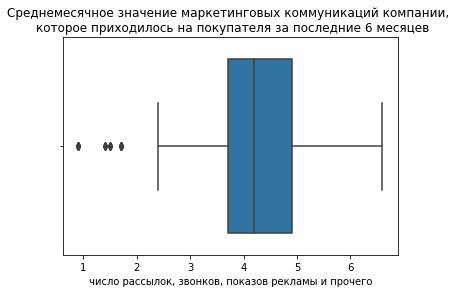

In [23]:
sns.boxplot(x=market_file['маркет_актив_6_мес'])
plt.title('Среднемесячное значение маркетинговых коммуникаций компании, \n которое приходилось на покупателя за последние 6 месяцев')
plt.xlabel('число рассылок, звонков, показов рекламы и прочего')
plt.show()

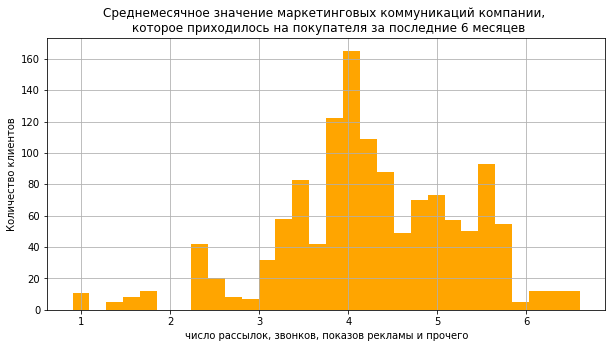

In [24]:
market_file['маркет_актив_6_мес'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=30, color='orange')
plt.xlim()
plt.title('Среднемесячное значение маркетинговых коммуникаций компании, \n которое приходилось на покупателя за последние 6 месяцев')
plt.ylabel('Количество клиентов')
plt.xlabel('число рассылок, звонков, показов рекламы и прочего')
plt.show()


Нормальное распределение c отклонениями. Выбросы есть на отметках между 1 и 2. Но это могут быть просто клиенты, с которыми невозможно было комуницировать по некоторым причинам.

In [25]:
print("Количество выбросов в market_file['маркет_актив_6_мес'] =", (market_file['маркет_актив_6_мес'] < 2).sum())

Количество выбросов в market_file['маркет_актив_6_мес'] = 36


И их слишком много, что бы их удалять.

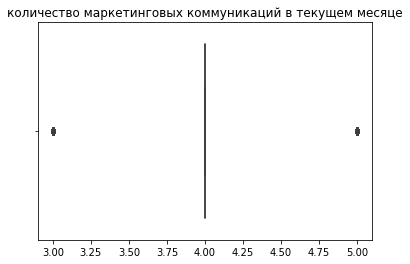

In [26]:
sns.boxplot(x=market_file['маркет_актив_тек_мес'])
plt.title('количество маркетинговых коммуникаций в текущем месяце')
plt.xlabel('')
plt.show()

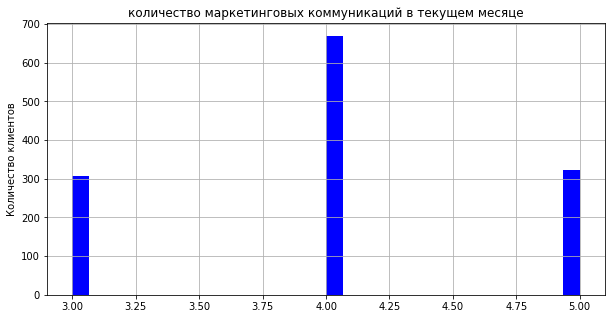

In [27]:
market_file['маркет_актив_тек_мес'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=30, color='blue')
plt.xlim()
plt.title('количество маркетинговых коммуникаций в текущем месяце')
plt.ylabel('Количество клиентов')
plt.show()

Распределение нормальное.
И тут, видимо возможно только 3 значения. (3, 4, 5)

In [28]:
market_file['маркет_актив_тек_мес'].unique()

array([5, 4, 3])

Из этого можно сделать категориальный признак.

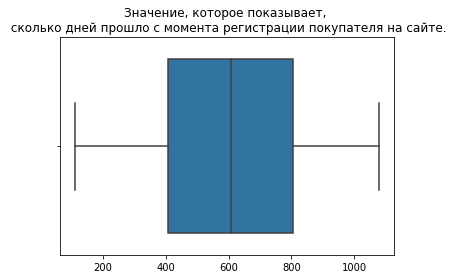

In [29]:
sns.boxplot(x=market_file['длительность'])
plt.title('Значение, которое показывает, \n сколько дней прошло с момента регистрации покупателя на сайте.')
plt.xlabel('')
plt.show()

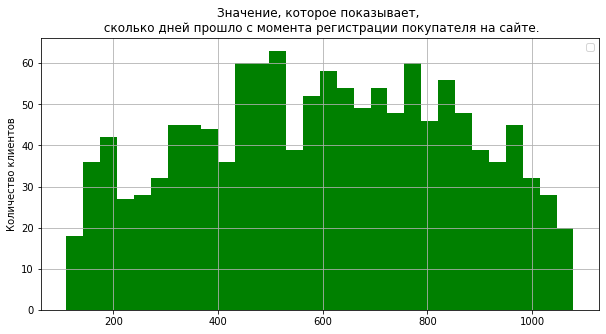

In [30]:
market_file['длительность'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=30, color='green')
plt.title('Значение, которое показывает, \n сколько дней прошло с момента регистрации покупателя на сайте.')
plt.legend(labels=[])
plt.ylabel('Количество клиентов')
plt.show()

Нормальное распределение без выбросов

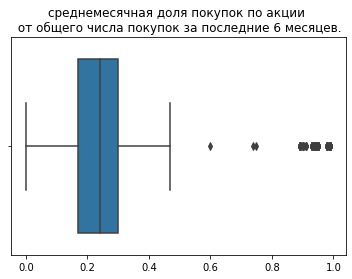

In [31]:
sns.boxplot(x=market_file['акционные_покупки'])
plt.title('среднемесячная доля покупок по акции \n от общего числа покупок за последние 6 месяцев.')
plt.xlabel('')
plt.show()

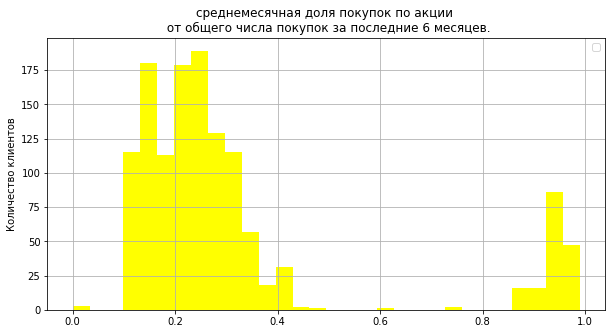

In [32]:
market_file['акционные_покупки'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=30, color='yellow')
plt.title('среднемесячная доля покупок по акции \n от общего числа покупок за последние 6 месяцев.')
plt.legend(labels=[])
plt.ylabel('Количество клиентов')
plt.show()

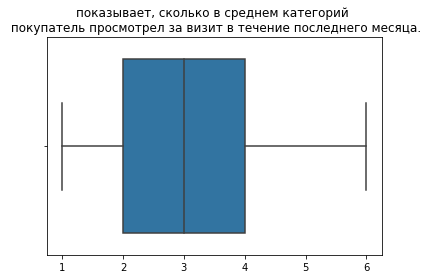

In [33]:
sns.boxplot(x=market_file['средний_просмотр_категорий_за_визит'])
plt.title('показывает, сколько в среднем категорий \n покупатель просмотрел за визит в течение последнего месяца.')
plt.xlabel('')
plt.show()

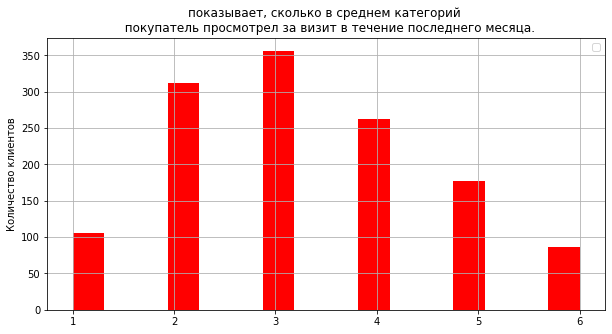

In [34]:
market_file['средний_просмотр_категорий_за_визит'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=16, color='red')
plt.title('показывает, сколько в среднем категорий \n  покупатель просмотрел за визит в течение последнего месяца.')
plt.legend(labels=[])
plt.ylabel('Количество клиентов')
plt.show()

Нормальное распределение без выбросов

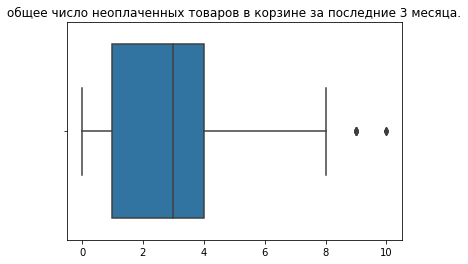

In [35]:
sns.boxplot(x=market_file['неоплаченные_продукты_штук_квартал'])
plt.title('общее число неоплаченных товаров в корзине за последние 3 месяца.')
plt.xlabel('')
plt.show()

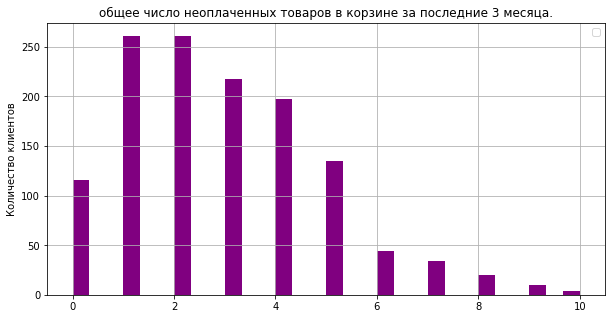

In [36]:
market_file['неоплаченные_продукты_штук_квартал'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=30, color='purple')
plt.title('общее число неоплаченных товаров в корзине за последние 3 месяца.')
plt.legend(labels=[])
plt.ylabel('Количество клиентов')
plt.show()

Нормальное распределение

In [37]:
print("Количество выбросов в market_file['неоплаченные_продукты_штук_квартал'] =",
      (market_file['неоплаченные_продукты_штук_квартал'] > 8).sum())

Количество выбросов в market_file['неоплаченные_продукты_штук_квартал'] = 14


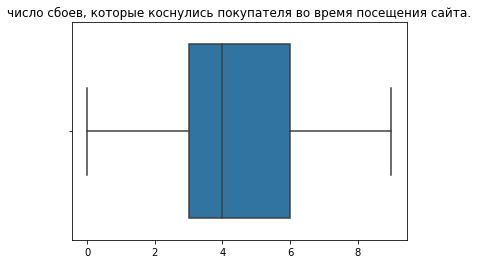

In [38]:
sns.boxplot(x=market_file['ошибка_сервиса'])
plt.title('число сбоев, которые коснулись покупателя во время посещения сайта.')
plt.xlabel('')
plt.show()

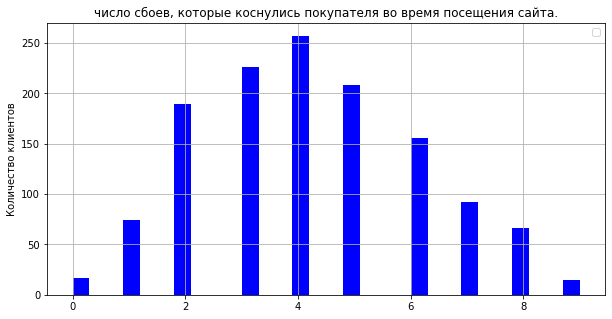

In [39]:
market_file['ошибка_сервиса'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=30, color='blue')
plt.title('число сбоев, которые коснулись покупателя во время посещения сайта.')
plt.legend(labels=[])
plt.ylabel('Количество клиентов')
plt.show()

Нормальное распределение без выбросов.

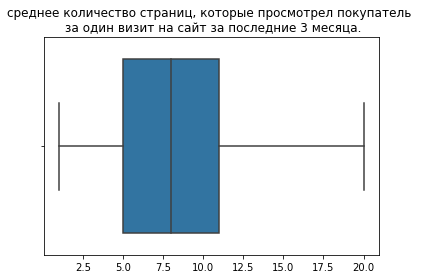

In [40]:
sns.boxplot(x=market_file['страниц_за_визит'])
plt.title('среднее количество страниц, которые просмотрел покупатель \n за один визит на сайт за последние 3 месяца.')
plt.xlabel('')
plt.show()

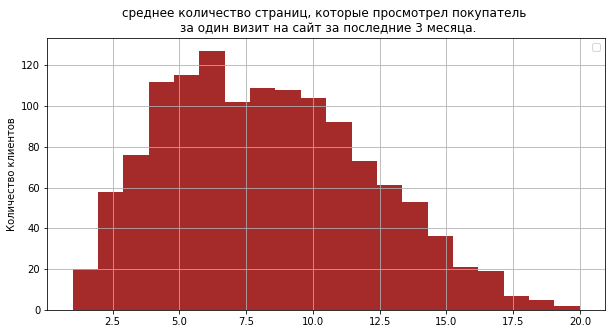

In [41]:
market_file['страниц_за_визит'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=20, color='brown')
plt.title('среднее количество страниц, которые просмотрел покупатель \n за один визит на сайт за последние 3 месяца.')
plt.legend(labels=[])
plt.ylabel('Количество клиентов')
plt.show()

Нормальное распределение без выбросов

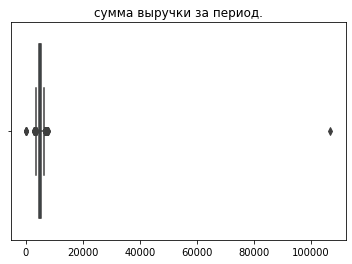

In [42]:
sns.boxplot(x=market_money['выручка'])
plt.title('сумма выручки за период.')
plt.xlabel('')
plt.show()

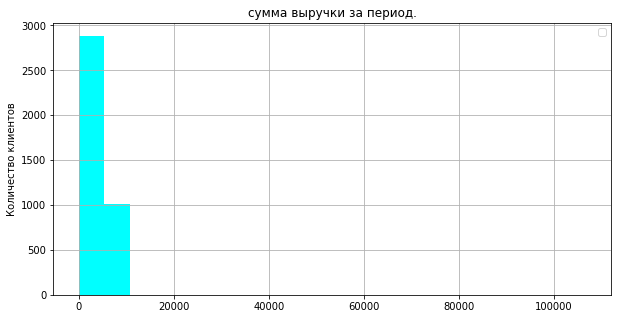

In [43]:
market_money['выручка'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=20, color='aqua')
plt.title('сумма выручки за период.')
plt.legend(labels=[])
plt.ylabel('Количество клиентов')
plt.show()

In [44]:
print("Количество выбросов в market_money['выручка'] =", (market_money['выручка'] > 20000).sum())

Количество выбросов в market_money['выручка'] = 1


Не может лишь один из многих так сильно закупиться за один месяц. Разница от медианного значения слишком велика.

In [45]:
# Замена аномально большого значения на медиану
market_money.loc[market_money['выручка'] > 20000, 'выручка'] = market_money['выручка'].median()


print("Количество выбросов в market_money['выручка'] =", (market_money['выручка'] > 20000).sum())

Количество выбросов в market_money['выручка'] = 0


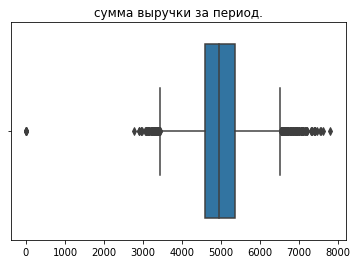

In [46]:
sns.boxplot(x=market_money['выручка'])
plt.title('сумма выручки за период.')
plt.xlabel('')
plt.show()

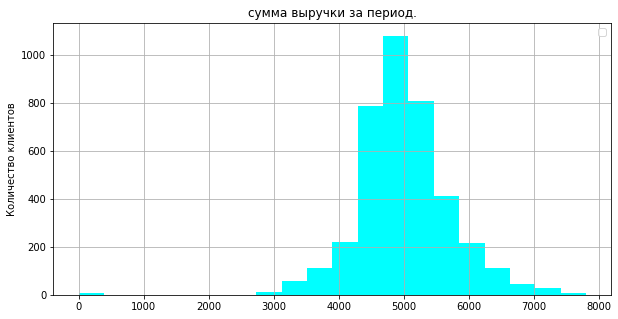

In [47]:
market_money['выручка'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=20, color='aqua')
plt.title('сумма выручки за период.')
plt.legend(labels=[])
plt.ylabel('Количество клиентов')
plt.show()

Распределение нормальное, с выбросами около нуля. Но учитывая то, что это значение выручки с клиента, то можно предположить что он просто ничего не купил. (то есть неактивный пользователь. С ними мы будем разбираться позже.)

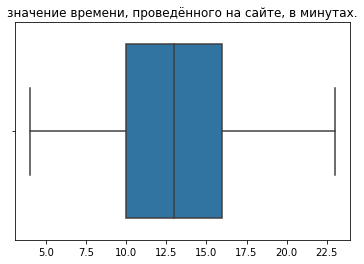

In [48]:
sns.boxplot(x=market_time['минут'])
plt.title('значение времени, проведённого на сайте, в минутах.')
plt.xlabel('')
plt.show()

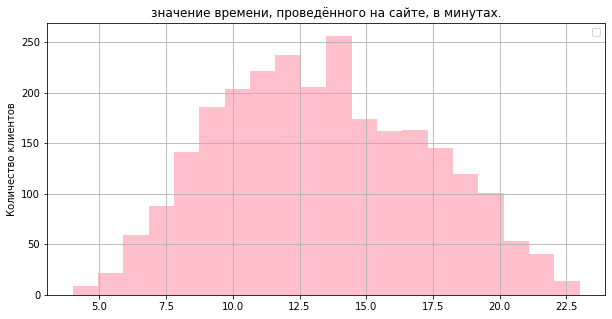

In [49]:
market_time['минут'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=20, color='pink')
plt.title('значение времени, проведённого на сайте, в минутах.')
plt.legend(labels=[])
plt.ylabel('Количество клиентов')
plt.show()

Распределение нормальное без выбросов.

In [50]:
money.head()

,id,прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


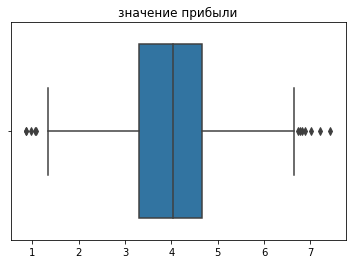

In [51]:
sns.boxplot(x=money['прибыль'])
plt.title('значение прибыли')
plt.xlabel('')
plt.show()

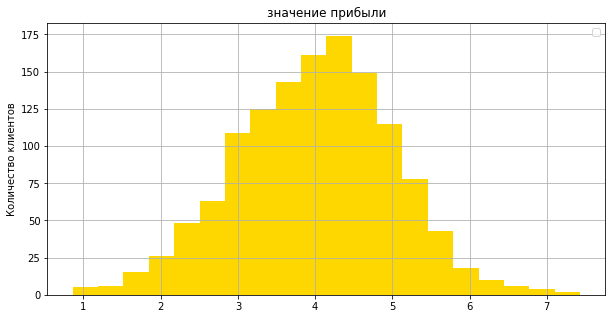

In [52]:
money['прибыль'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=20, color='gold')
plt.title('значение прибыли')
plt.legend(labels=[])
plt.ylabel('Количество клиентов')
plt.show()

Распределение нормальное

###  Визуализация и разбор категориальных признаков

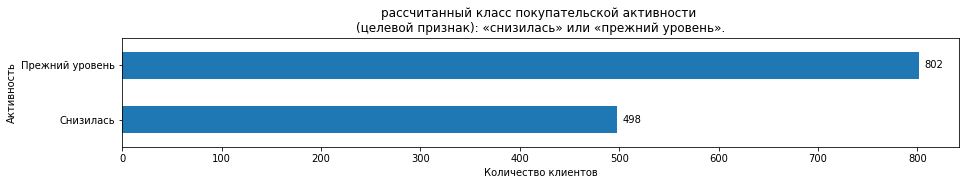

In [53]:
ax = market_file['покупательская_активность'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='рассчитанный класс покупательской активности \n(целевой признак): «снизилась» или «прежний уровень».'
)


for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')


plt.xlabel('Количество клиентов')
plt.ylabel('Активность')


plt.show()

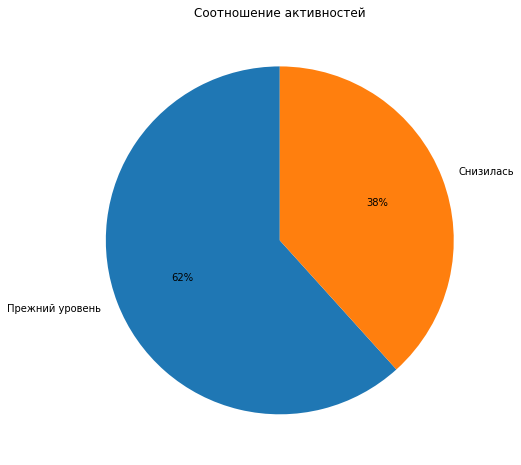

In [54]:
ax = market_file.pivot_table(index='покупательская_активность', values='id', aggfunc='count').reset_index()

plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['покупательская_активность'], startangle=90, autopct = "%.0f%%")
plt.title('Соотношение активностей')
plt.show()

Соотношение в пользу прежнего уровня.

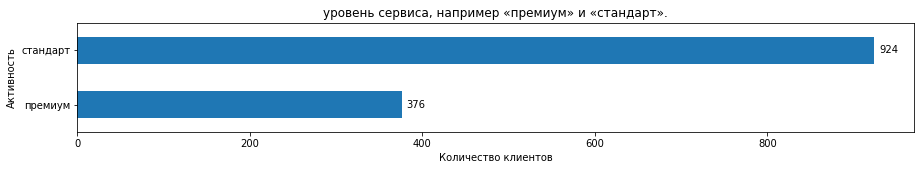

In [55]:
ax = market_file['тип_сервиса'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='уровень сервиса, например «премиум» и «стандарт».'
)


for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')


plt.xlabel('Количество клиентов')
plt.ylabel('Активность')


plt.show()

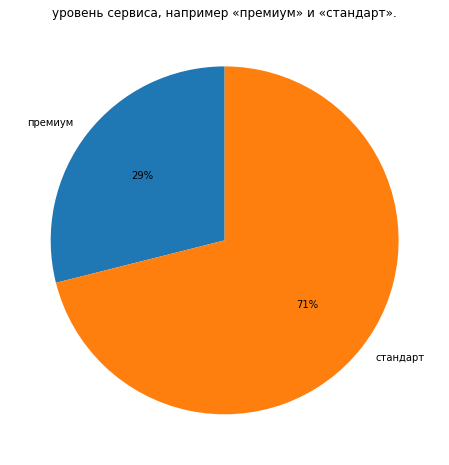

In [56]:
ax = market_file.pivot_table(index='тип_сервиса', values='id', aggfunc='count').reset_index()

plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['тип_сервиса'], startangle=90, autopct = "%.0f%%")
plt.title('уровень сервиса, например «премиум» и «стандарт».')
plt.show()

Подавляющее большинство без премиума.

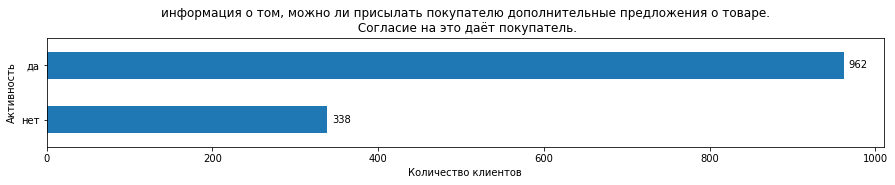

In [57]:
ax = market_file['разрешить_сообщать'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='информация о том, можно ли присылать покупателю дополнительные предложения о товаре.\n Согласие на это даёт покупатель.'
)


for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')


plt.xlabel('Количество клиентов')
plt.ylabel('Активность')


plt.show()

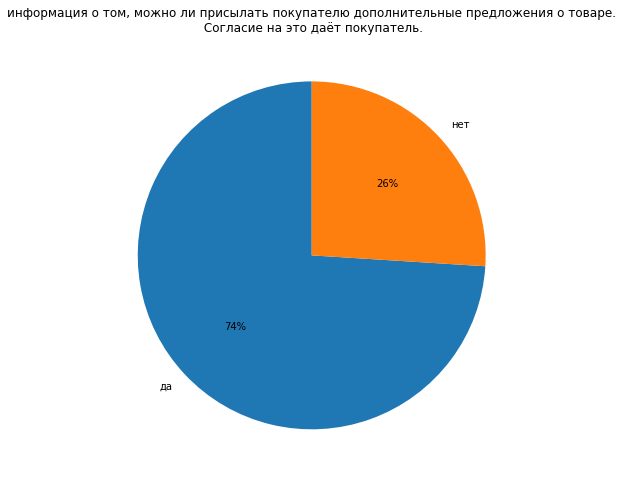

In [58]:
ax = market_file.pivot_table(index='разрешить_сообщать', values='id', aggfunc='count').reset_index()

plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['разрешить_сообщать'], startangle=90, autopct = "%.0f%%")
plt.title('информация о том, можно ли присылать покупателю дополнительные предложения о товаре.\n Согласие на это даёт покупатель.')
plt.show()

Большинству нужны рассылки с этого магазина.

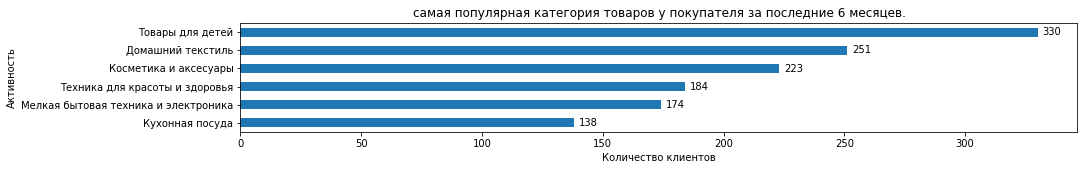

In [59]:
ax = market_file['популярная_категория'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='самая популярная категория товаров у покупателя за последние 6 месяцев.'
)


for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')


plt.xlabel('Количество клиентов')
plt.ylabel('Активность')


plt.show()

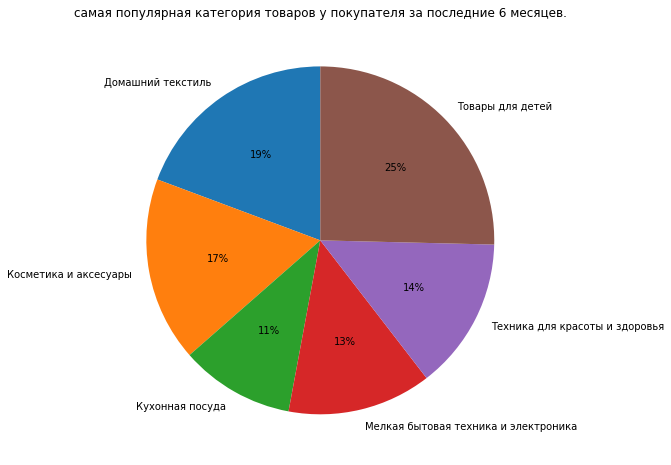

In [60]:
ax = market_file.pivot_table(index='популярная_категория', values='id', aggfunc='count').reset_index()

plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['популярная_категория'], startangle=90, autopct = "%.0f%%")
plt.title('самая популярная категория товаров у покупателя за последние 6 месяцев.')
plt.show()

Товары для детей обеспечивает четверть от всех остальных. В этом есть логика.

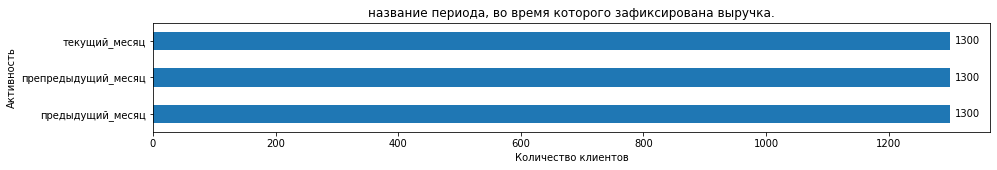

In [61]:
ax = market_money['период'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='название периода, во время которого зафиксирована выручка.'
)


for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')


plt.xlabel('Количество клиентов')
plt.ylabel('Активность')


plt.show()

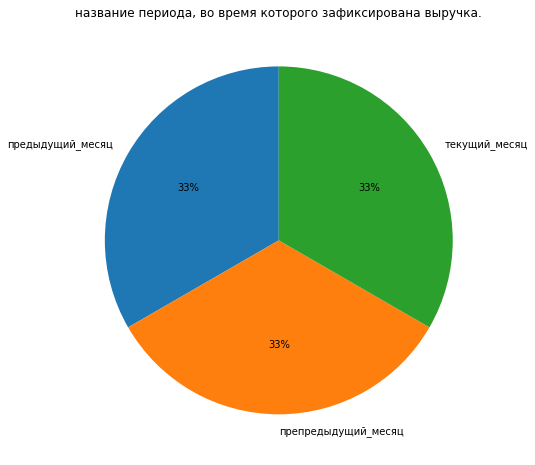

In [62]:
ax = market_money.pivot_table(index='период', values='id', aggfunc='count').reset_index()

plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['период'], startangle=90, autopct = "%.0f%%")
plt.title('название периода, во время которого зафиксирована выручка.')
plt.show()

Для каждого клиента зафиксирована своя активность. Выводов с этого сделать нельзя.

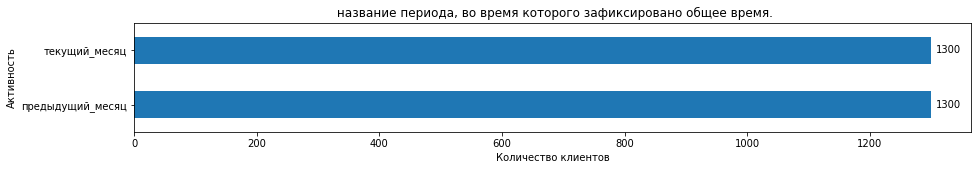

In [63]:
ax = market_time['период'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title=' название периода, во время которого зафиксировано общее время.'
)


for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')


plt.xlabel('Количество клиентов')
plt.ylabel('Активность')


plt.show()

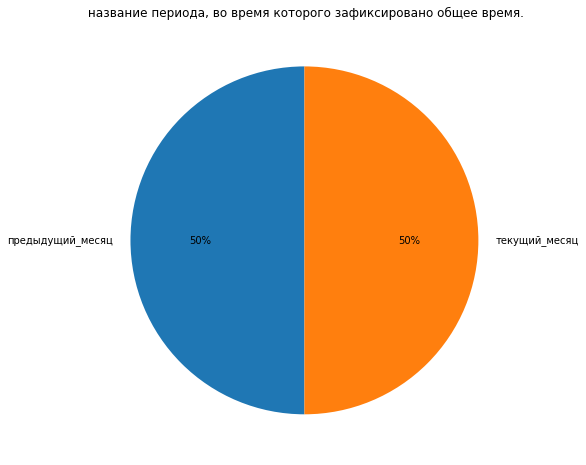

In [64]:
ax = market_time.pivot_table(index='период', values='id', aggfunc='count').reset_index()

plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['период'], startangle=90, autopct = "%.0f%%")
plt.title(' название периода, во время которого зафиксировано общее время.')
plt.show()

Тоже самое, что и для клиентов

Теперь по тз я отберу клиентов с покупательской активностью не менее трёх месяцев, то есть таких, которые что-либо покупали в этот период. Оформлю выводы по результатам шага.

Эти данные я буду извлекать market_money.csv. Там как раз данные за три месяца. Просто отберу тех, чья выручка не 0 и составлю по их id отдельную категорию.

In [65]:
market_money_active_users = market_money.groupby('id').prod().query('выручка > 0').reset_index()

# Объединяем market_file с market_money_active_users по 'id'
merged_data = market_file.merge(market_money_active_users[['id']], on='id', how='left', indicator=True)

#Добавляем новый столбец 'активный_пользователь', который будет True для активных пользователей и False для остальных
market_file['активный_пользователь'] = merged_data['_merge'] == 'both'

market_file.head()


,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,активный_пользователь
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5,False
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,True
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,True
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,True
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,True


In [66]:
market_file[market_file['активный_пользователь'] == False]

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,активный_пользователь
0,215348,Снизилась,премиум,да,3.4,5,121,0.0,Товары для детей,6,2,1,5,False
9,215357,Снизилась,стандарт,да,3.9,5,154,0.0,Техника для красоты и здоровья,3,3,9,5,False
11,215359,Снизилась,стандарт,да,4.6,5,110,0.0,Домашний текстиль,4,2,4,2,False


Их так мало. Я отсею клиентов с покупательской активностью не менее трёх месяцев.

In [67]:
market_file = market_file[market_file['активный_пользователь'] == True]
market_file.drop('активный_пользователь', axis=1, inplace=True)
market_file.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2
5,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4


Промежуточный вывод. Данные обработаны и готовы к дальнейшим манипуляциям над ними.

## Шаг 4. Объединение таблиц

### Объедининение таблицы market_file.csv, market_money.csv, market_time.csv.


Данные о прибыли из файла money.csv при моделировании нам не понадобятся. 


In [68]:
market_file.head()


,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2
5,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4


In [69]:
market_money.head()

,id,период,выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [70]:
market_time.head()

,id,период,минут
0,215348,текущий_месяц,14
1,215348,предыдущий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдущий_месяц,12
4,215350,текущий_месяц,13


market_money содержит больше данных. Там есть информация о трех месяцах, в то время как в market_time информация о трех. Именно поэтому обьединять их по id нельзя, ибо тогда периоды могут друг другу несоответствовать.

Придется обьединить их по периоду, что бы избежать потри данных, но 'препредыдущий_месяц' останется без 'минут'

Можно перевести id в такой вид, что они будут уникальными в каждой строчке без потери данных, просто создав отдельные столбцы с разными категориями помесячных минут в виде новых столбцов.

In [71]:
market_time_reset = market_time.set_index(['id', 'период']).минут.unstack()
market_time_reset.head()

период,предыдущий_месяц,текущий_месяц
id,,
215348,13,14
215349,12,10
215350,8,13
215351,11,13
215352,8,11


In [72]:
market_time_reset.columns.values[0] = 'минуты_предыдущий_месяц'  # Переименовываем вторую колонку
market_time_reset.columns.values[1] = 'минуты_текущий_месяц'  # Переименовываем третью колонку
market_time_reset = market_time_reset.reset_index()
market_time_reset.head()

период,id,минуты_предыдущий_месяц,минуты_текущий_месяц
0,215348,13,14
1,215349,12,10
2,215350,8,13
3,215351,11,13
4,215352,8,11


Тоже самое с market_money

In [73]:
market_money_reset= market_money.set_index(['id', 'период']).выручка.unstack()
market_money_reset.head()

период,предыдущий_месяц,препредыдущий_месяц,текущий_месяц
id,,,
215348,0.0,0.0,3293.1
215349,5216.0,4472.0,4971.6
215350,5457.5,4826.0,5058.4
215351,6158.0,4793.0,6610.4
215352,5807.5,4594.0,5872.5


In [74]:
market_money_reset.columns.values[0] = 'выручка_предыдущий_месяц' 
market_money_reset.columns.values[1] = 'выручка_препредыдущий_месяц'
market_money_reset.columns.values[2] = 'выручка_текущий_месяц' 
market_money_reset = market_money_reset.reset_index()
market_money_reset.head()

период,id,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц
0,215348,0.0,0.0,3293.1
1,215349,5216.0,4472.0,4971.6
2,215350,5457.5,4826.0,5058.4
3,215351,6158.0,4793.0,6610.4
4,215352,5807.5,4594.0,5872.5


И теперь я добавлю эти столбцы в market_file по id, создав новый датафрейм market_data

In [75]:
market_data = pd.merge(market_file, market_time_reset[['id', 'минуты_предыдущий_месяц', 'минуты_текущий_месяц']], on='id', how='left')
market_data.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,минуты_предыдущий_месяц,минуты_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,12,10
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,8,13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,11,13
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,8,11
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,10,10


In [76]:
market_data = pd.merge(market_data, market_money_reset[['id', 'выручка_предыдущий_месяц', 'выручка_препредыдущий_месяц', 'выручка_текущий_месяц']], on='id', how='left')
market_data.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,минуты_предыдущий_месяц,минуты_текущий_месяц,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,12,10,5216.0,4472.0,4971.6
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,8,13,5457.5,4826.0,5058.4
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,11,13,6158.0,4793.0,6610.4
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,8,11,5807.5,4594.0,5872.5
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,10,10,4738.5,5124.0,5388.5


 ### Проверка на пропуски и дубликаты

In [77]:
display(market_data.isna().sum())
print(market_data.duplicated().sum())

id                                     0
покупательская_активность              0
тип_сервиса                            0
разрешить_сообщать                     0
маркет_актив_6_мес                     0
маркет_актив_тек_мес                   0
длительность                           0
акционные_покупки                      0
популярная_категория                   0
средний_просмотр_категорий_за_визит    0
неоплаченные_продукты_штук_квартал     0
ошибка_сервиса                         0
страниц_за_визит                       0
минуты_предыдущий_месяц                0
минуты_текущий_месяц                   0
выручка_предыдущий_месяц               0
выручка_препредыдущий_месяц            0
выручка_текущий_месяц                  0
dtype: int64

0


Я учел то, что данные о выручке и времени на сайте находятся в одном столбце для всех периодов.

В итоговой таблице был создан отдельный столбец для каждого периода. (в будущем это помешало моему анализу важности признаков)

## Шаг 5. Корреляционный анализ

Проведу корреляционный анализ признаков в количественной шкале в итоговой таблице для моделирования. 

Сделаю выводы о мультиколлинеарности и при необходимости устраню её.

In [78]:
market_data_2 = pd.get_dummies(market_data, drop_first=True)  # тут я перевожу категориальные признаки в количественные


In [79]:
market_data.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,минуты_предыдущий_месяц,минуты_текущий_месяц,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,12,10,5216.0,4472.0,4971.6
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,8,13,5457.5,4826.0,5058.4
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,11,13,6158.0,4793.0,6610.4
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,8,11,5807.5,4594.0,5872.5
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,10,10,4738.5,5124.0,5388.5


In [80]:
phik_matrix = market_data.phik_matrix(interval_cols=['маркет_актив_6_мес',
                                                     'длительность',
                                                    'акционные_покупки',
                                                    'выручка_предыдущий_месяц',
                                                    'выручка_препредыдущий_месяц',
                                                    'выручка_текущий_месяц'])
display(phik_matrix['покупательская_активность'])

/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable id is large: 1297. Are you sure this is not an interval variable? Analysis for pairs of variables including id can be slow.
  warnings.warn(


id                                     1.000000
покупательская_активность              1.000000
тип_сервиса                            0.132247
разрешить_сообщать                     0.000000
маркет_актив_6_мес                     0.546370
маркет_актив_тек_мес                   0.000000
длительность                           0.101767
акционные_покупки                      0.506991
популярная_категория                   0.298036
средний_просмотр_категорий_за_визит    0.539221
неоплаченные_продукты_штук_квартал     0.404382
ошибка_сервиса                         0.223697
страниц_за_визит                       0.746825
минуты_предыдущий_месяц                0.603903
минуты_текущий_месяц                   0.569310
выручка_предыдущий_месяц               0.227280
выручка_препредыдущий_месяц            0.495174
выручка_текущий_месяц                  0.195470
Name: покупательская_активность, dtype: float64

interval columns not set, guessing: ['id', 'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность', 'акционные_покупки', 'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'страниц_за_визит', 'минуты_предыдущий_месяц', 'минуты_текущий_месяц', 'выручка_предыдущий_месяц', 'выручка_препредыдущий_месяц', 'выручка_текущий_месяц', 'покупательская_активность_Снизилась', 'тип_сервиса_стандарт', 'разрешить_сообщать_нет', 'популярная_категория_Косметика и аксесуары', 'популярная_категория_Кухонная посуда', 'популярная_категория_Мелкая бытовая техника и электроника', 'популярная_категория_Техника для красоты и здоровья', 'популярная_категория_Товары для детей']


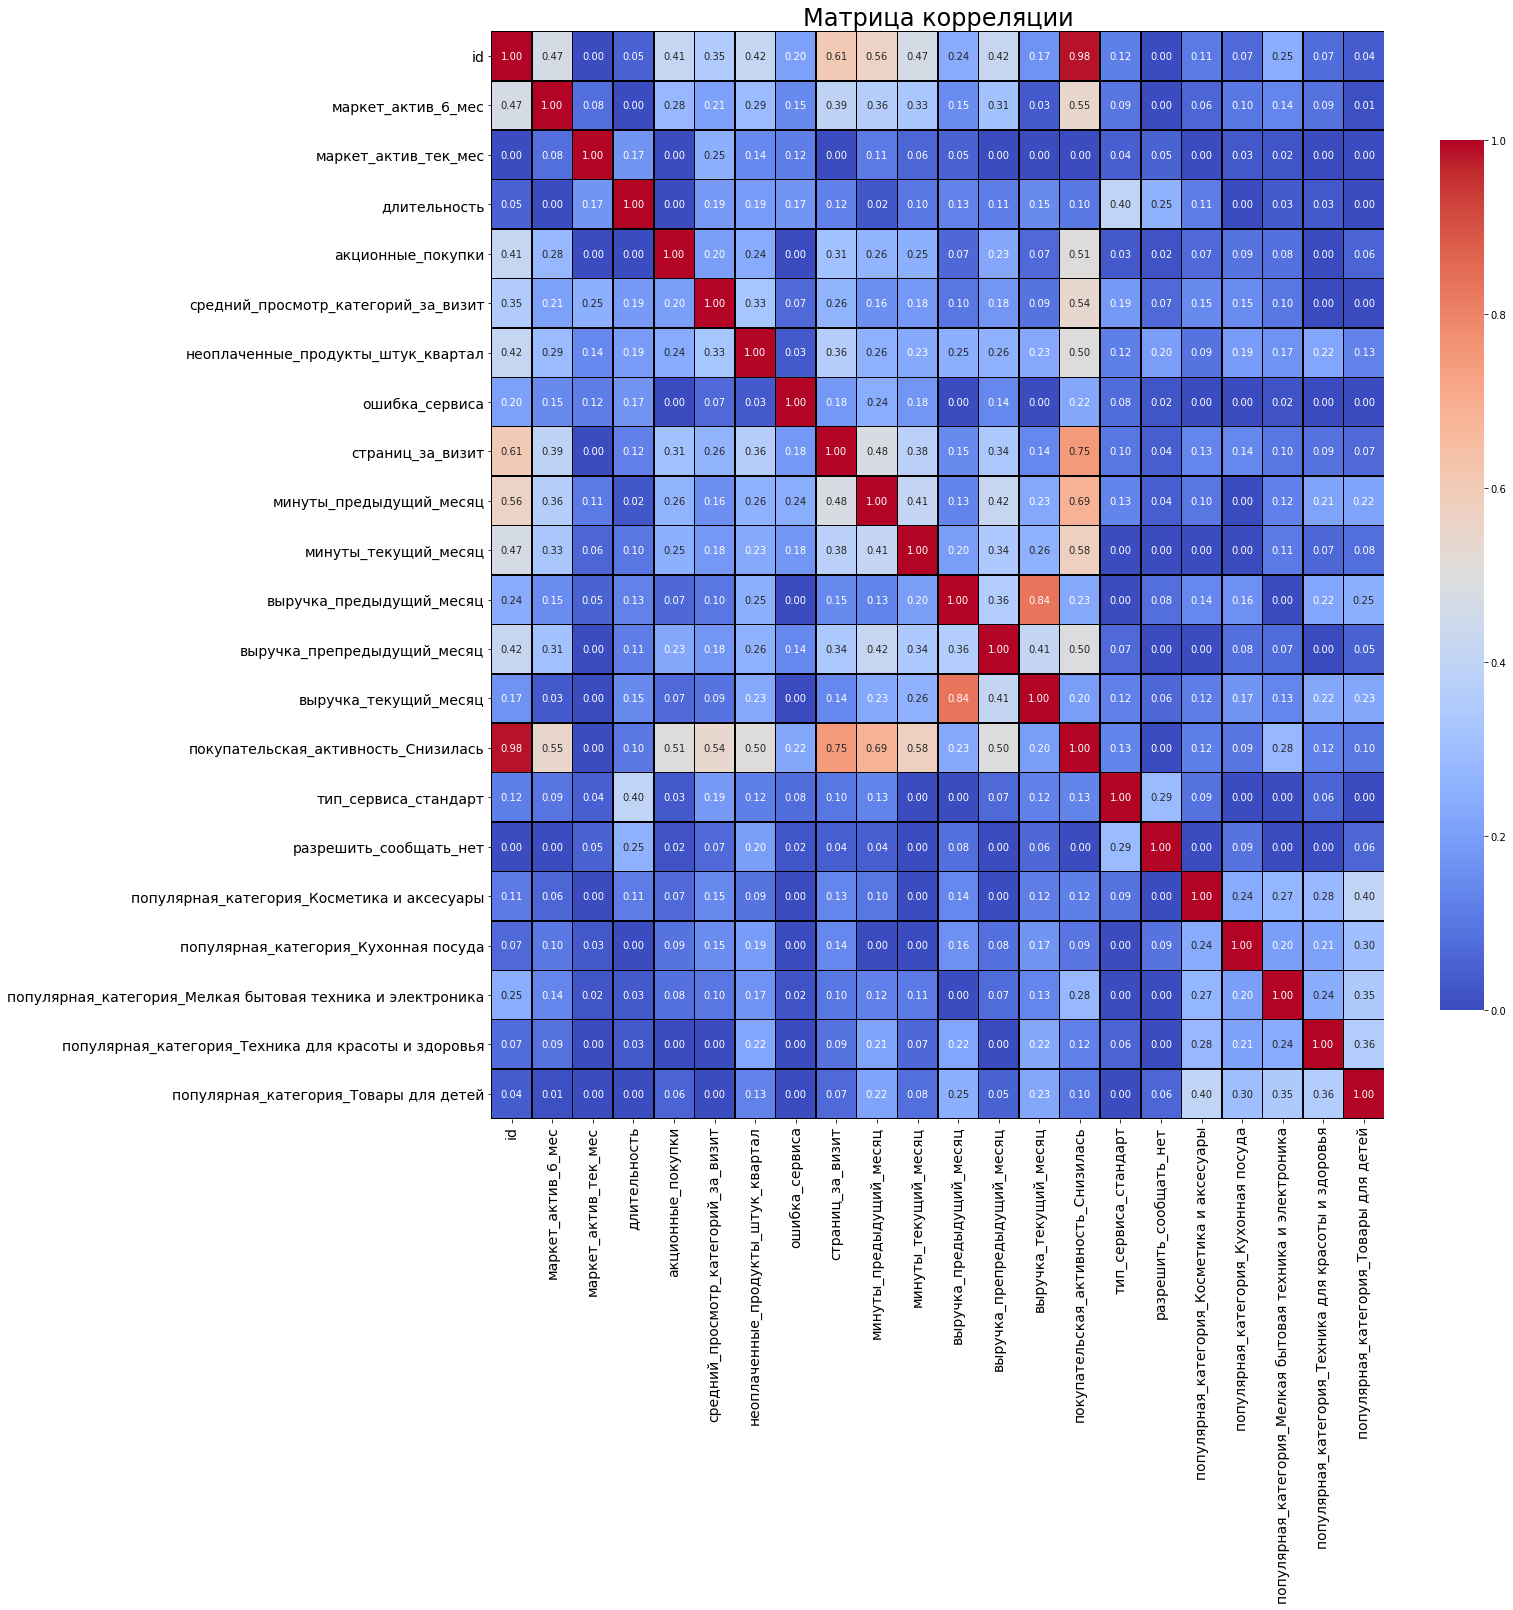

In [81]:
plt.figure(figsize=(20, 20))


sns.heatmap(
    market_data_2.phik_matrix(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',  
    linewidths=.5, 
    linecolor='black',
    cbar_kws={"shrink": .8},
)


plt.title('Матрица корреляции', fontsize=24)


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.show()

Итак, мы выяснили коэффициенты кореляции 'покупательская_активность' (целевого признака) c остальными признаками.
По убыванию:

страниц за визит 0.75

минуты предыдущий месяц 0.69

минуты текущий месяц 0.58

Маркет актив за 6 месяцев 0.55

Средный просмотр категорий за визит 0,54

Акционные покупки 0,51

выручка препредыдущий месяц 0.50

Неоплачивенные продукты штук квартал 0.50

популярная категория мелкая бытовая техника и электроника 0.28

выручка предыдущий месяц 0.23

ошибка сервиса 0.22

выручка текущий месяц 0.20

тип сервиса стандарт 0.13

популярная категория техника для красоты и здоровья 0.12

популярная категория косметика и аксессуары 0.12

популярная категория товары для детей 0.10

Длительность 0.1

Маркет актив за текущий месяц 0

разрешить сообщать нет 0.00


Мультиколлинеарность в иных рассматриваемых признаках наблюдается в выручке за текущий месяц по отношению к предыдущему месяцу (0.84)

Такого быть не может, ибо как выручка за один месяц может влиять на выручку из другого?

Судя по дальнейшим выводам о признаке выручки за текущий месяц, мной будет принято решение об удалении его, поскольку этот признак содержит незаконченные данные, которые лишь помешают проекту.


Будем рассматривать те, которые имеют коэффициент кореляции 0.50 и выше. Выводы по каждому:

1) страниц за визит 0.75. Ну тут влияние очевидно. Если пользователь что то ищет, значит он что то хочет купить.

2) минуты предыдущий месяц 0.69 и минуты текущий месяц 0.58. По теории выше, минуты за текущий месяц могут быть неполными данными, а потому то, что коэффициент кореляции ниже обосновано. (потом уберу последний признак)

3)  Маркет актив за 6 месяцев имеет 0.55, что очень контрастирует с маркет активом за текущий месяц 0.

    Из этого можно сделать вывод, что либо этот текущий месяц все еще продолжается, и его итоги никак не повлияли на покупательскую активность, либо в этот месяц вообще ничего не происходило для повышения покупательской активности. А зря. Это один из наиболее корелируемых признаков. Я учту это в выводе.

3.1) Но предыдущий вывод не обьясняет 0 кореляцию. Магазин старается повышать активность, а потому странно видеть отсутствие маркет активов. Скорее всего текущий месяц действительно не заполнен полностью.

4) Средный просмотр категорий за визит 0,54. Аналогично с первым выводом.

5) Акционные покупки 0,51. Дополняет третий вывод. Акции входят в Маркет_актив, а потому повышают активность

6) выручка препредыдущий месяц 0.50. Контрастирует с выручкой за текущий месяц в 0.20. Возможно, текущий месяц не закончен и был посчитан заранее, а потому эти данные ложные.

7) Неоплачивенные продукты штук квартал 0.50 - ну раз в корзине лежат продукты, значит из купят. Но видимо не всегда.



О признаках со слабой кореляцией.

1) популярная_категория 0.298036 - В этой категории 5 признаков. А поотдельности они:

    1.1)популярная категория мелкая бытовая техника и электроника 0.28

    1.2)популярная категория техника для красоты и здоровья 0.12

    1.3)популярная категория косметика и аксессуары 0.12

    1.4)популярная категория товары для детей 0.10 (хоть и самая популярная категория, но не она в основном держит актив покупателей)

    1.5)популярная категория кухонная посуда 0.09 

2) выручка_предыдущий_месяц 0.227280

3) ошибка_сервиса 0.223697

4) тип_сервиса 0.132247

5) длительность 0.101767

6) разрешить_сообщать 0.000000

In [82]:
market_data_model_clear = market_data_2.drop([ 
    'маркет_актив_тек_мес',
    'минуты_текущий_месяц',  
    'выручка_текущий_месяц', 
    'разрешить_сообщать_нет', 
    'популярная_категория_Косметика и аксесуары',
    'популярная_категория_Кухонная посуда', 
    'популярная_категория_Мелкая бытовая техника и электроника',
    'популярная_категория_Техника для красоты и здоровья', 
    'популярная_категория_Товары для детей'], axis=1)

In [83]:
market_data_model_clear.head()

,id,маркет_актив_6_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,минуты_предыдущий_месяц,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,покупательская_активность_Снизилась,тип_сервиса_стандарт
0,215349,4.4,819,0.75,4,4,2,5,12,5216.0,4472.0,1,0
1,215350,4.9,539,0.14,5,2,1,5,8,5457.5,4826.0,1,1
2,215351,3.2,896,0.99,5,0,6,4,11,6158.0,4793.0,1,1
3,215352,5.1,1064,0.94,3,2,3,2,8,5807.5,4594.0,1,1
4,215353,3.3,762,0.26,4,1,1,4,10,4738.5,5124.0,1,1


In [84]:
market_data_model_clear = market_data_model_clear.merge(market_data[['id', 'популярная_категория']], on='id', how='left')
    
    



В результате корреляционного анализа мной были исключены признаки, которые слабо коррелировали с целевой переменной. Также была устранена мультиколлинеарность, и удалены данные, которые могли создавать помехи в анализе.
Кроме того, было обнаружено, что есть категория клиентов, которые посещают сайт, долго просматривают страницы и добавляют товары в корзину, но в конечном итоге не совершают покупку. При этом частота маркетинговых коммуникаций с такими пользователями оказывается довольно высокой.


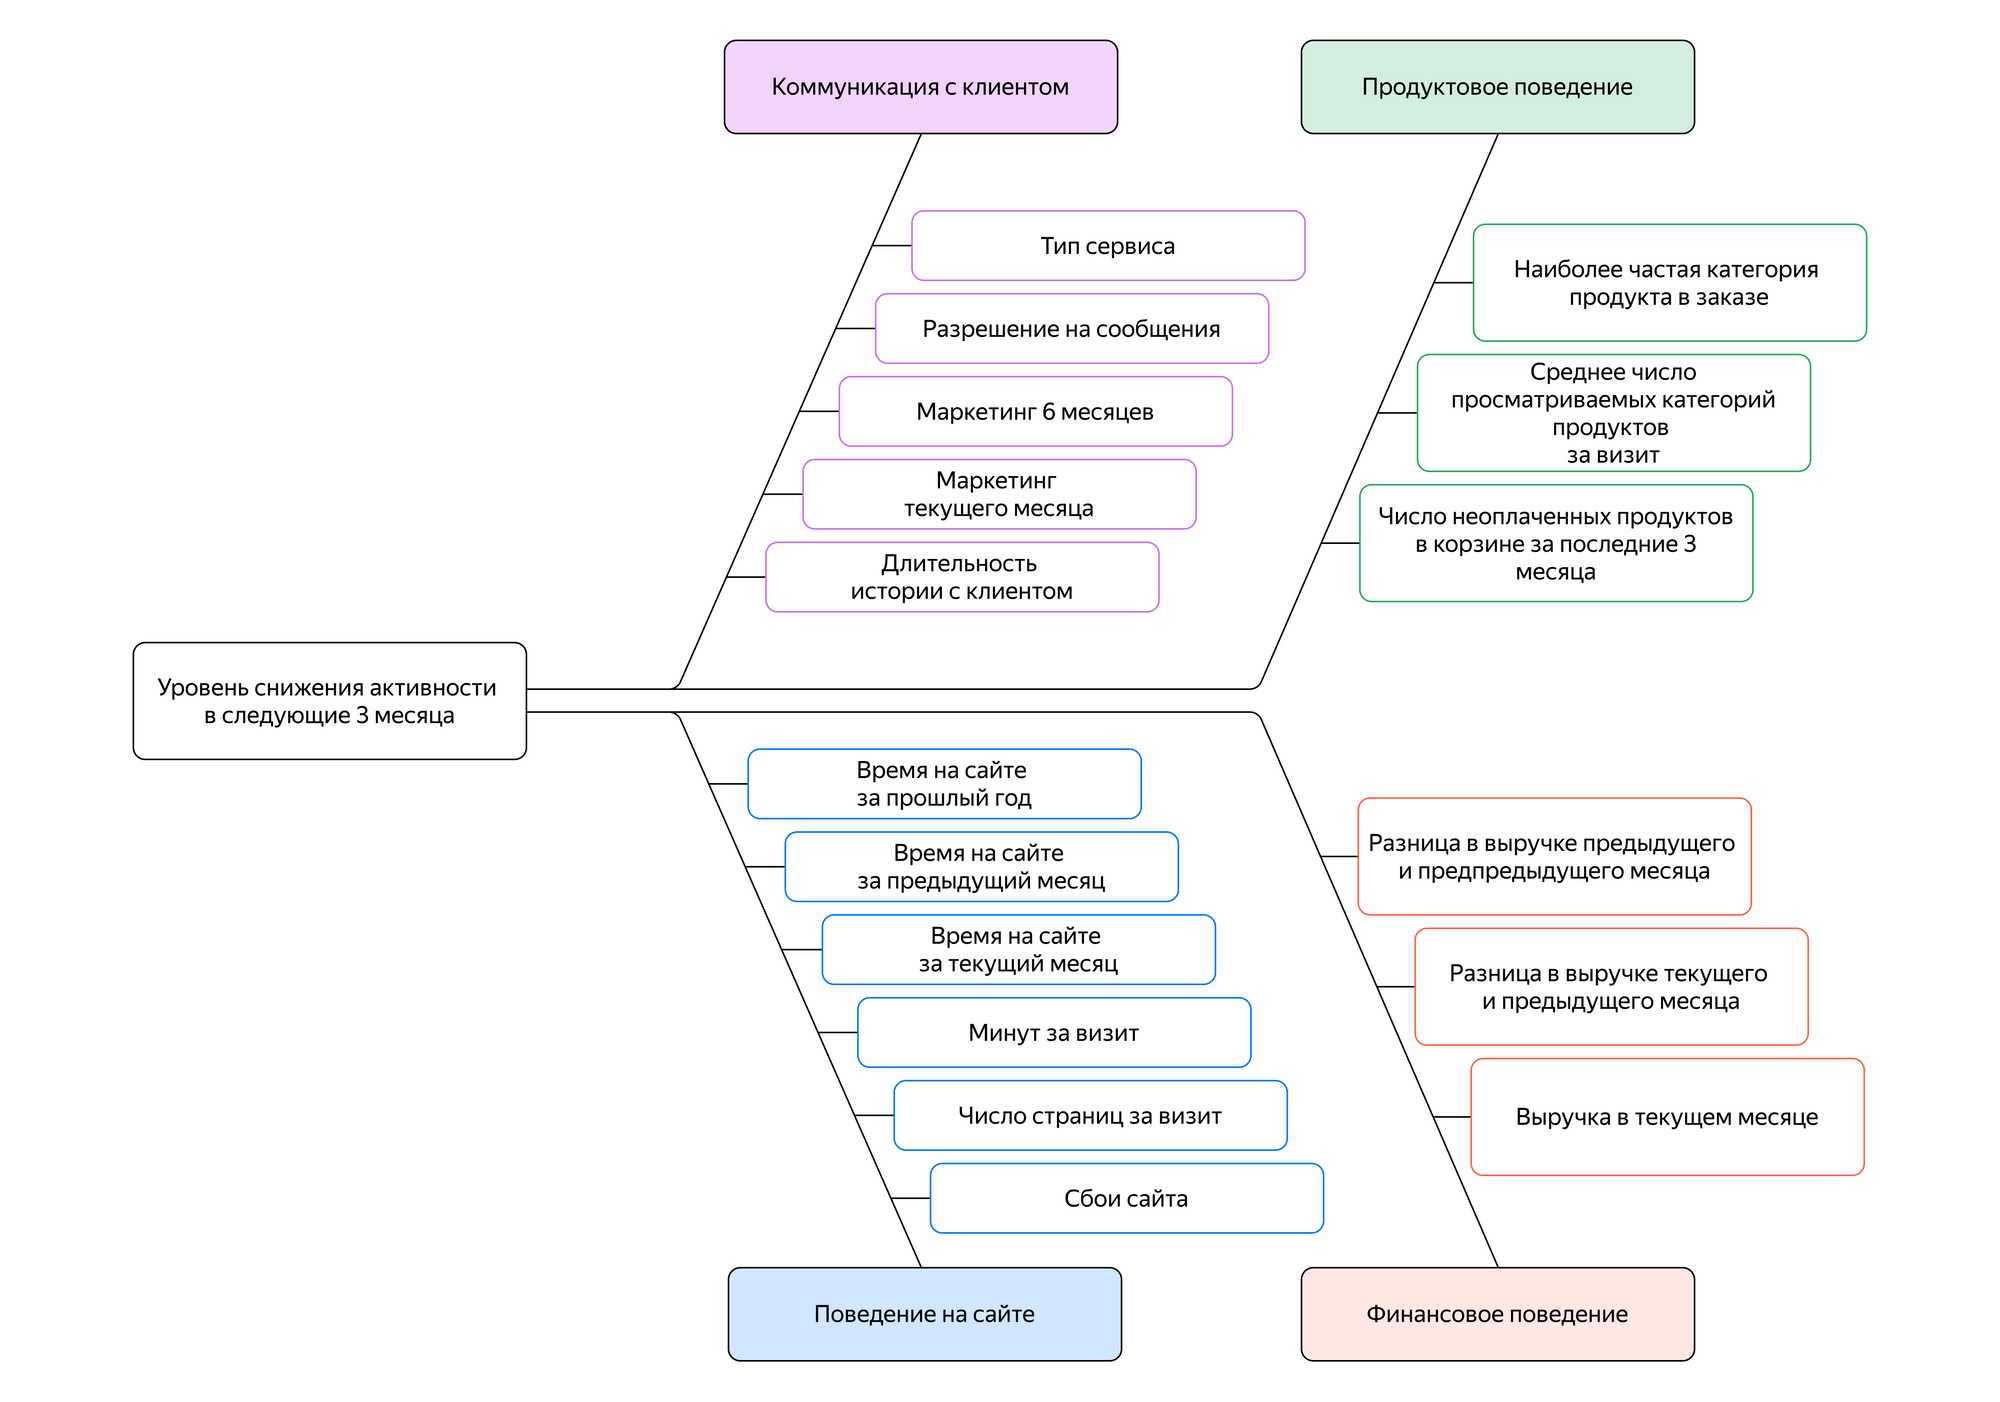

## Шаг 6. Использование пайплайнов

Выше Я подготовил данные для пайплайна. Вот ---> market_data_model_clear

In [85]:
market_data_model_clear.head() 

,id,маркет_актив_6_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,минуты_предыдущий_месяц,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,покупательская_активность_Снизилась,тип_сервиса_стандарт,популярная_категория
0,215349,4.4,819,0.75,4,4,2,5,12,5216.0,4472.0,1,0,Товары для детей
1,215350,4.9,539,0.14,5,2,1,5,8,5457.5,4826.0,1,1,Домашний текстиль
2,215351,3.2,896,0.99,5,0,6,4,11,6158.0,4793.0,1,1,Товары для детей
3,215352,5.1,1064,0.94,3,2,3,2,8,5807.5,4594.0,1,1,Товары для детей
4,215353,3.3,762,0.26,4,1,1,4,10,4738.5,5124.0,1,1,Домашний текстиль


Сначала обозначим, какие данные требуют масштабирования, а какие — кодирования. 

(признаки кодируем разными методами)

Введём обозначения для типов исходных данных:

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    market_data_model_clear.drop(['id',
                     'покупательская_активность_Снизилась'
                    ], axis=1).reset_index(drop=True),
    market_data_model_clear['покупательская_активность_Снизилась'],
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = market_data_model_clear['покупательская_активность_Снизилась']
)

In [87]:
print(f'X_train.shape= {X_train.shape}',end='\n')
print(f'y_train.shape= {y_train.shape}',end='\n')
print(f'X_test.shape= {X_test.shape}', end='\n')
print(f'y_test.shape= {y_test.shape}', end='\n')

X_train.shape= (972, 12)
y_train.shape= (972,)
X_test.shape= (325, 12)
y_test.shape= (325,)


In [88]:
ohe_pipe = Pipeline(
    [
        (
            'SimpleImputer_ohe',
            SimpleImputer(missing_values=np.nan,strategy='most_frequent')        
        ),
        (
            'ohe',
            OneHotEncoder(drop='first')
        )
    ]
)

In [89]:
ord_pipe = Pipeline(
    [
        (
            'SimpleImputer_ord_befoure',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'onehot',
            OneHotEncoder(handle_unknown='ignore')
        ),
        (
            'SimpleImputer_ord_after',
            SimpleImputer(missing_values=np.nan,strategy='most_frequent')
        )
    ]
)



In [90]:
market_data_model_clear.head()

,id,маркет_актив_6_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,минуты_предыдущий_месяц,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,покупательская_активность_Снизилась,тип_сервиса_стандарт,популярная_категория
0,215349,4.4,819,0.75,4,4,2,5,12,5216.0,4472.0,1,0,Товары для детей
1,215350,4.9,539,0.14,5,2,1,5,8,5457.5,4826.0,1,1,Домашний текстиль
2,215351,3.2,896,0.99,5,0,6,4,11,6158.0,4793.0,1,1,Товары для детей
3,215352,5.1,1064,0.94,3,2,3,2,8,5807.5,4594.0,1,1,Товары для детей
4,215353,3.3,762,0.26,4,1,1,4,10,4738.5,5124.0,1,1,Домашний текстиль


In [91]:
ohe_columns = ['тип_сервиса_стандарт']
ord_columns = ['популярная_категория']
num_columns = ['маркет_актив_6_мес',
    'акционные_покупки',
    'ошибка_сервиса', 
    'средний_просмотр_категорий_за_визит',
    'неоплаченные_продукты_штук_квартал',
    'страниц_за_визит',
    'минуты_предыдущий_месяц',
    'выручка_предыдущий_месяц',
    'выручка_препредыдущий_месяц'] 



Применю все изученные модели. Для этого использую пайплайны.


Пайплайны помогают автоматизировать действия с данными, которые повторяются из раза в раз. 



###  Подготовка данных ColumnTransformer. 

Количественные и категориальные признаки обработаю в пайплайне раздельно. 

Для кодирования категориальных признаков использую как минимум два кодировщика, для масштабирования количественных — как минимум два скейлера.


In [92]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num',StandardScaler(), num_columns)
    ],
    remainder='passthrough'
)


In [93]:
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)


### Обучение четырёх моделей 

KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression() и  SVC().

Для каждой из них подберу как минимум один гиперпараметр.

Выберу подходящую для задачи метрику, аргументирую свой выбор. 

Использую эту метрику при подборе гиперпараметров. 


~(с SVC возникли некоторые трудности. Нейросети не помогли мне решить данную проблему)~

In [94]:
param_grid = [
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(1, 20),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    },
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 11),
        'models__max_features': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    {
        'models': [SVC(random_state=RANDOM_STATE, probability=True)],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE,
                                      solver='liblinear',
                                      penalty='l1')],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
]

In [95]:
randomized_search = RandomizedSearchCV(
    pipe_final,
    param_grid,
    cv           = 5,
    scoring      = 'roc_auc',
    random_state = RANDOM_STATE,
    n_jobs       = -1
)

ROC-AUC была выбрана мной так как она хорошо подходит для оценки моделей c такими несбалансированными признаками, которые я дал оной.



### Выбор лучшей модели м.о.

In [ ]:
randomized_search.fit(X_train, y_train)

In [ ]:
print('Лучшая модель', randomized_search.best_estimator_)
print ('и её метрика', randomized_search.best_score_)

Вывод. С пайплайнами я обучил ~3~ 4 модели и отобрал от них лучший.

Вот этот.

LogisticRegression



In [ ]:
y_pred_proba = randomized_search.best_estimator_.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)

print('Метрика ROC AUC на тестовых данных, для контроля переобучения:', roc_auc)

## Шаг 7. Анализ важности признаков

### Оценка важности признаков для лучшей модели 


Построю график важности с помощью метода SHAP. 

In [ ]:

X_train_2 = randomized_search.best_estimator_.named_steps['preprocessor'].fit_transform(X_train)
X_test_2 = randomized_search.best_estimator_.named_steps['preprocessor'].transform(X_test)


feature_names = randomized_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()


X_test_2 = pd.DataFrame(X_test_2, columns=feature_names)


explainer = shap.Explainer(randomized_search.best_estimator_.named_steps['models'], X_train_2)

shap_values = explainer(X_test_2)


# Обученная модель
model = search_logistic.best_estimator_

# Создаём объект Explainer и получаем значения SHAP
explainer = shap.LinearExplainer(model.named_steps['classifier'], X_train)
shap_values = explainer.shap_values(X_train)



In [ ]:
shap.summary_plot(shap_values, X_train_2, plot_type='bar', feature_names=feature_names)

Глядя на SHAP визуализацию, мы можем видеть наиболее важные признаки. По неоплаченым продуктам, минутам, страницам за визит и просмотрам категорий это хорошо видно. 

По всем этим признакам можно попробовать разбить покупателей на сегменты.

### Выводы о значимости признаков:

какие признаки мало значимы для модели;
какие признаки сильнее всего влияют на целевой признак;
как можно использовать эти наблюдения при моделировании и принятии бизнес-решений.

## Шаг 8. Сегментация покупателей

### Сегментация покупателей. 


Использую результаты моделирования и данные о прибыльности покупателей.


In [ ]:
market_data_profit = market_data_2.merge(money, on='id')
market_data_profit.head()

In [ ]:
interval_cols = {
    'маркет_актив_6_мес',
    'акционные_покупки',
    'средний_просмотр_категорий_за_визит',
    'неоплаченные_продукты_штук_квартал',
    'страниц_за_визит',
    'минуты_предыдущий_месяц',
    'выручка_предыдущий_месяц',
    'выручка_препредыдущий_месяц',
    'покупательская_активность_Снизилась',
    'прибыль'
}

plt.figure(figsize=(20, 20))

sns.heatmap(
    market_data_profit.drop('id', axis=1).phik_matrix(
        interval_cols=interval_cols
    ), annot=True, fmt='.2f'
)

plt.show()

Можно увидеть, что на прибыльность влияют признаки длительность, ошибка сервиса, выручки, популярная категория, средний просмотр категорий за визит.

In [ ]:
market_data_profit.head()

их мы и исключим при использовании регрессии

In [ ]:
market_data_profit = market_data_profit.merge(market_data[['id', 'популярная_категория']], on='id', how='left')

In [ ]:
series = randomized_search.predict_proba(
    market_data_profit.drop(
        ['id', 
        'покупательская_активность_Снизилась', 'популярная_категория_Косметика и аксесуары',
         'популярная_категория_Кухонная посуда',
         'популярная_категория_Мелкая бытовая техника и электроника',
         'популярная_категория_Техника для красоты и здоровья',
         'популярная_категория_Товары для детей'

        ], axis=1
    )
)[:,1]

market_data_profit['вероятность_падения_актива'] = series

### Выбор группы покупателей


предложу, как увеличить её покупательскую активность: 


In [ ]:
market_data_profit.plot.scatter(x='вероятность_падения_актива',
                       y='прибыль',
                       title='прибыль клиента\nвероятность падения актива',
                       xlabel='актив',
                       ylabel='прибыль',  alpha=0.5, c='MediumPurple')
plt.show()

Ну, две группы по вероятности точно есть. А что по выручке? До 0.3 и после 0.8. Усредню. Пусть граница будет 0.55

In [ ]:
for name in ['выручка_текущий_месяц']:
    plt.figure(figsize=(10, 4))
    plt.title(f'Исследуется "{name}"')
    plt.xlabel('Вероятность принадлежности к классу')
    plt.ylabel(f'Значение')
    plt.scatter(x=market_data_profit['вероятность_падения_актива'], 
                y=market_data_profit[name],
                alpha=0.5)

Проведу графическое и аналитическое исследование группы покупателей.

In [ ]:
market_data_profit.head()

In [ ]:


def show_scatter(data, ax, col_name, color):
    data.plot.scatter(ax=ax,
                       x=col_name,
                       y='вероятность_падения_актива',
                       color=color,
                       title=f'прибыль клиента\nвероятность падения актива {col_name}',
                       xlabel=col_name,
                       ylabel='покупательская_активность_Снизилась')



In [ ]:
def show_bar(data, ax, col_name, color):
    pivot = data.pivot_table(index=col_name, values='вероятность_падения_актива', aggfunc='median')
    pivot.columns = ['median']
    pivot.sort_values(by='median', ascending=True, inplace=True)
    pivot.plot.barh(ax=ax,
                    color=color,
                    title=f'прибыль клиента\nвероятность падения актива {col_name}',
                    xlabel='',
                    ylabel='покупательская_активность_Снизилась')




In [ ]:
def hist_box(data, column):
    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    plt.xlabel(f'Значения столбца "{column}"')
    plt.ylabel('Частота')
    plt.title(f'Гистограмма для "{column}"')
    sns.histplot(data[column], color='green')

In [ ]:
threshold_probability = 0.55
threshold_profit = 3


not_elita_market_data = market_data_profit[
    (market_data_profit['вероятность_падения_актива'] >= threshold_probability) & 
    (market_data_profit['прибыль'] >= threshold_profit)
]
elita_market_data = market_data_profit[
    ~((market_data_profit['вероятность_падения_актива'] >= threshold_probability) & 
    (market_data_profit['прибыль'] >= threshold_profit))
]

# Определение числовых и категориальных столбцов
num_cols = [
    'маркет_актив_6_мес',
    'акционные_покупки',
    'средний_просмотр_категорий_за_визит',
    'страниц_за_визит',
    'ошибка_сервиса',
    'минуты_предыдущий_месяц'
]

cat_cols = [
    'популярная_категория_Косметика и аксесуары',
    'неоплаченные_продукты_штук_квартал'
]

fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(8, 15))

# для числовых
for i, col in enumerate(num_cols):
    show_scatter(not_elita_market_data, axes[i, 0], col, 'MediumPurple')
    show_scatter(elita_market_data, axes[i, 1], col, 'black')

# для категориальных
for i, col in enumerate(cat_cols):
    show_bar(not_elita_market_data, axes[i + len(num_cols), 0], col, 'MediumPurple')
    show_bar(elita_market_data, axes[i + len(num_cols), 1], col, 'black')

plt.subplots_adjust(right=2, top=3)
plt.show()

cat_df = ['сервис', 'рассылка', 'категория']
for name in num_cols:
    hist_box(elita_market_data, name)

### Сделаю выводы о сегментах:

какой сегмент я взял для дополнительного исследования?

Анализ проводился на вероятность_падения_актива и прибыли.

Но исключительно потому, что по заданию требовалось разработать модель, которая предскажет вероятность снижения покупательской активности.

Рекомендации по выводам выше будут ниже.

## Шаг 9. Общий вывод

Шаг 9. Общий вывод

Сделаю общий вывод:

Начнем с главного. Мне очень сильно мешало то, что я не знал в какой единице измерения вычисляется прибыль, а следовательно с чисто визуальной точки зрения было трудно определить ценность каждого клиента до момента сравнения выручки и вероятности падения активности. А моей осонвной задачей был анализ данных модели и прибыльности клиентов. Потому моя рекомендация: по подробнее описывать в тз, в каком виде эта информация находится

К претензиям выше так же добавляется несовершенство данных за текущий месяц, потому что мне кажется, что они либо не совершенны, либо полны выбросов. Но анализ данных опроверг вторую теорию, а потому эти данные просто неокончены и мешают анализу.

(Есть вероятность, что я просто не совсем понял задачу, потому как в практикуме я проходил немного отличное от того, что делал в проекте)




Все что я в итоге имел в анализе данных за полгода это 2 последних месяца.

Мной были заменены пропуски, устранены явные, неявные дубликаты, исправлена опечатка, переименованы некоторые столбцы.
Мной была найдена оптимальная модель машинного обучения(Logistic Regression) и была проанализирована значимость признаков у выбранной модели.
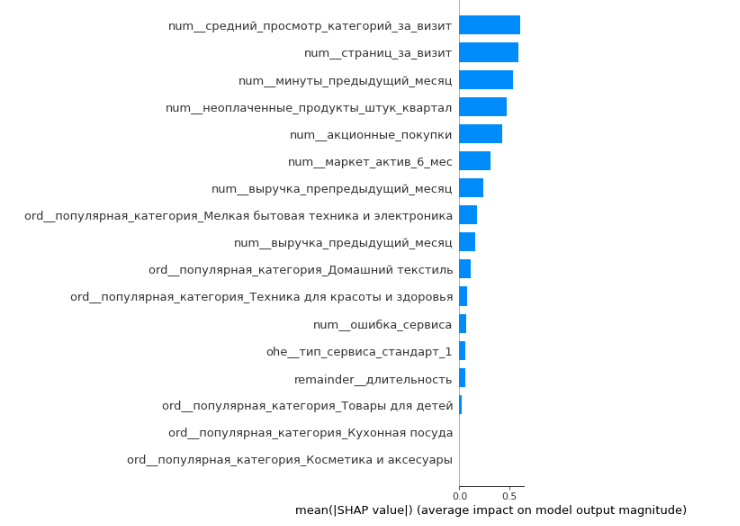
К моей ВЕЛИКОЙ РАДОСТИ, я смог сделать модель SVC. 


Теперь по подробнее про вероятность_падения_актива.

1) Клиенты с высокой активностью есть среди клиентов, закупавшихся во время акционные_покупки, но большинство из них входят в покупательская_активность_Снизилась.
Это означает, что клиент ждет скидок, а затем просто уходит, получив желаемое. Это логично, но я все равно не советую убирать акции, так как величина клиентов слишком велика в эти моменты.

Рекомендации: проводить акции среди новых пользователей, что бы не баловать старых и не давать повода им уйти, если последние не получили желаемого. Если вышеизложеная рекомендация не реализуема, то просто стоит немного изменить подход. Например проводить акции среди отдельных категорий товара. А вот на какие (популярные или нет), сказать без обновленных данных нельзя.

Акционные покупки очень сложная тема, которая требует очень тонкой регулировки без крайностей.

2) малое количество категорий, корелирует с увеличением риска снижения активности. Я не знаю почему, но СМЕЮ предположить, что:


Теория 1. Интерфейс сайта недружелюбен к пользователю настолько, что им некомфортно переключаться между категориями. Надо поменять алгоритмы рекомендации и сделать удобную домашнюю страницу, что бы пользователь листал сайт дольше.

Теория 2. Он просто зашел на категорию, не нашел того, что хотел и ушел. Я видел категории, и они довольно специфичны, но это уже проблемы тематики сайта. Посоветовать здесь ничего нельзя, так как советовать расширить магазину свой ассортимент глупая идея. Может рекомендации добавить? Это будет способствовать удержанию пользователей на сайте

3) минуты, проведенные на сайте, уменьшают вероятность. Совет по поводу интерфейса стал более актуален

4) ошибка_сервиса на сайте увеличивает вероятность_падения_актива. Ну, тут мне сказать нечего. Надо сфокусировать основные силы на эту проблему.

5) Среди покупателей наиболее популярны товары для детей, но активность создавала категория мелкая бытовая техника и электроника(с этим признаком возникли проблемы при анализе данных)




Обнаружена и устранена мультикоррелиарность в признаке с выручкой за текущий месяц путем его устранения за ненадобностью.